### Imports and Config

In [8]:
# The below code augments images by overlaying them on random background images
import os
import cv2
import csv
import random
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt

# Set random seeds for reproducibility
random.seed(42)
np.random.seed(42)

# Folders you must have
INPUT_DIR = Path("input")          # input/chatgpt, input/gemini, input/claude
BG_DIR    = Path("backgrounds")    # background images (desktop/wallpapers/etc)
OUT_DIR   = Path("output_aug")     # output folder for augmented images

CLASSES = ["chatgpt", "gemini", "claude"]  # Classes of images to augment

IMG_EXTS = {".jpg", ".jpeg", ".png", ".bmp", ".webp"}  # Supported image file extensions

# Create output directory if it doesn't exist
OUT_DIR.mkdir(parents=True, exist_ok=True)
print("OUT_DIR:", OUT_DIR.resolve())

OUT_DIR: C:\IPCV\Homeassignment\ui-detector\output_aug


## Data Preparation - Loading and Validation

This code sets up the data pipeline for an image processing project:

1. list_images(): Helper function that recursively finds all image files in a directory
2. read_bgr(): Helper function that loads images using OpenCV (BGR format)
3. chatbot_paths dictionary: Organizes images by class/type for easy access
4. bg_paths list: Collects background images for data augmentation
5. Assertions: Validates minimum image counts (10+ per class, 10+ backgrounds)

**Purpose**: Prepares image data for training by organizing files and ensuring sufficient quantities exist.

In [9]:
# Helper functions
def list_images(folder: Path):  # List all image files in a folder (recursively)
    if not folder.exists():     # If folder doesn't exist, return empty list 
        return []               
    return sorted([p for p in folder.rglob("*") if p.suffix.lower() in IMG_EXTS])   

# Read image in BGR format
def read_bgr(path: Path):   
    img = cv2.imread(str(path), cv2.IMREAD_COLOR) # Read image using OpenCV 
    if img is None:                                 
        raise ValueError(f"Could not read image: {path}")  
    return img

# Build input lists
chatbot_paths = {}  
for cls in CLASSES: 
    p = INPUT_DIR / cls 
    imgs = list_images(p)  
    chatbot_paths[cls] = imgs   
    print(cls, "images:", len(imgs), "in", p)       

# Build background list
bg_paths = list_images(BG_DIR)   
print("background images:", len(bg_paths), "in", BG_DIR) 

# Sanity checks to ensure enough images are present for augmentation 
assert len(bg_paths) >= 10, "Add more backgrounds in backgrounds/ (try 20+)"    # Ensure at least 10 background images
for cls in CLASSES:                  
    assert len(chatbot_paths[cls]) >= 10, f"Add more images in input/{cls}/ (try 30+)"  # Ensure at least 10 images per class

chatgpt images: 13 in input\chatgpt
gemini images: 10 in input\gemini
claude images: 11 in input\claude
background images: 10 in backgrounds


## Image Augmentation Function

This function applies randomized transformations to simulate real-world variations in images:

1. Brightness/Contrast (90% chance): Randomly adjusts brightness (±20) and contrast (0.85-1.15x)
2. Saturation/Value (70% chance): Converts to HSV space and tweaks saturation (0.85-1.25x) and value (0.90-1.10x)
3. Gaussian Blur (35% chance): Applies mild blurring with 3x3 or 5x5 kernel
4. JPEG Artifacts (35% chance): Simulates compression artifacts by re-encoding with random quality (35-85%)

**Purpose**: Creates diverse training examples by simulating lighting conditions, camera quality, and compression variations - making models more robust to real-world image variations.

In [10]:
# Image augmentation function 
def apply_theme_transform(win_bgr): 
    win = win_bgr.copy().astype(np.float32) # Copy image and convert to float32

    # brightness/contrast
    if random.random() < 0.9:   # 90% chance to apply brightness/contrast adjustment
        alpha = random.uniform(0.85, 1.15)  # contrast 
        beta  = random.uniform(-20, 20)     # brightness
        win = win * alpha + beta    # apply brightness/contrast adjustment

    # saturation tweak
    if random.random() < 0.7:       # 70% chance to apply saturation adjustment
        hsv = cv2.cvtColor(np.clip(win,0,255).astype(np.uint8), cv2.COLOR_BGR2HSV).astype(np.float32)   # convert to HSV color space
        hsv[...,1] *= random.uniform(0.85, 1.25)    # adjust saturation
        hsv[...,2] *= random.uniform(0.90, 1.10)    # adjust value/brightness
        win = cv2.cvtColor(np.clip(hsv,0,255).astype(np.uint8), cv2.COLOR_HSV2BGR).astype(np.float32)   # convert back to BGR color space

    # slight blur
    if random.random() < 0.35:  # 35% chance to apply Gaussian blur
        k = random.choice([3,5])
        win = cv2.GaussianBlur(win, (k,k), 0)   # apply Gaussian blur

    # jpeg artifacts simulation
    if random.random() < 0.35:  # 35% chance to simulate JPEG compression artifacts
        q = random.randint(35, 85)
        enc = cv2.imencode(".jpg", np.clip(win,0,255).astype(np.uint8), [int(cv2.IMWRITE_JPEG_QUALITY), q])[1]  # encode image as JPEG
        win = cv2.imdecode(enc, cv2.IMREAD_COLOR).astype(np.float32)    # decode JPEG back to image

    # clip to valid range and convert back to uint8 
    return np.clip(win, 0, 255).astype(np.uint8)

## Perspective Warp Function

This function applies random perspective distortion to simulate different viewing angles:

1. Source Points: Defines the original image corners
2. Random Destination: Generates slightly shifted corner points within a 12% boundary
3. Perspective Transform: Creates a 3x3 transformation matrix using cv2.getPerspectiveTransform
4. Warp Application: Applies the perspective warp with cv2.warpPerspective, using border replication to fill empty areas

**Purpose**: Simulates how objects appear when viewed from different angles (like a chatbot window viewed from slightly above/below/sideways), helping models learn to recognize objects regardless of minor perspective changes.

In [11]:
# Perspective warp function
def perspective_warp(img_bgr, max_warp=0.12):   # Apply random perspective warp to an image 
    h, w = img_bgr.shape[:2]    # Get image height and width
    src = np.float32([[0,0],[w-1,0],[w-1,h-1],[0,h-1]]) 

    # Calculate maximum displacement for warping
    dx = w * max_warp   
    dy = h * max_warp   

    # Generate random destination points for warping
    dst = np.float32([  
        [random.uniform(0, dx), random.uniform(0, dy)], 
        [w-1-random.uniform(0, dx), random.uniform(0, dy)], 
        [w-1-random.uniform(0, dx), h-1-random.uniform(0, dy)], 
        [random.uniform(0, dx), h-1-random.uniform(0, dy)]
    ])

    # Compute perspective transform matrix and apply warp
    M = cv2.getPerspectiveTransform(src, dst)   
    warped = cv2.warpPerspective(img_bgr, M, (w, h), borderMode=cv2.BORDER_REPLICATE)   
    return warped

## Overlay Window Function

This function composites a window image onto a background with realistic transformations:

1. Perspective Warp (45% chance): Applies slight perspective distortion to the window
2. Theme Transform: Adjusts brightness, contrast, saturation, and adds blur/compression artifacts
3. Dynamic Scaling: Resizes window relative to background (18-75% of background width)
4. Random Placement: Positions window randomly within background bounds
5. Occluder Rectangle (35% chance): Adds overlapping rectangle to simulate UI elements
6. Context Cropping (30% chance): Randomly crops the background to simulate zoomed views

**Purpose**: Creates synthetic training data by placing chatbot windows on varied backgrounds with realistic variations in size, position, appearance, and occlusion - simulating real screenshot scenarios.

In [12]:
# Overlay window onto background image
def overlay_window(background_bgr, window_bgr): 
    """
    Paste window image onto background, safely clipped.
    Returns: composed_bgr, bbox(x1,y1,x2,y2) in composed coords
    """
    bg = background_bgr.copy() 
    H, W = bg.shape[:2]         

    win = window_bgr.copy() 

    # (1) random warp
    if random.random() < 0.45:  # 45% chance to apply perspective warp 
        win = perspective_warp(win, max_warp=random.uniform(0.05, 0.14))

    # (2) theme transform
    win = apply_theme_transform(win)    

    # (3) resize window relative to bg
    h, w = win.shape[:2]    
    target_scale = random.uniform(0.18, 0.75)   
    new_w = max(120, int(W * target_scale))     
    aspect = h / max(1, w)  
    new_h = max(90, int(new_w * aspect))    
    win = cv2.resize(win, (new_w, new_h), interpolation=cv2.INTER_AREA)  

    # (4) random position
    x1 = random.randint(0, max(0, W - new_w))   
    y1 = random.randint(0, max(0, H - new_h))   

    # clamp + compute paste region
    x1 = max(0, min(x1, W-1))   
    y1 = max(0, min(y1, H-1))   

    x2 = min(W, x1 + new_w)  
    y2 = min(H, y1 + new_h)  
    
    paste_w = x2 - x1  
    paste_h = y2 - y1   

    # crop window to fit paste region
    win_crop = win[:paste_h, :paste_w]  
    bg[y1:y2, x1:x2] = win_crop     

    # (5) occluder rectangle to simulate overlap
    if random.random() < 0.35:  # 35% chance to add occluder rectangle 
        occ_w = random.randint(int(paste_w*0.15), max(int(paste_w*0.45), int(paste_w*0.15)+1))  
        occ_h = random.randint(int(paste_h*0.15), max(int(paste_h*0.45), int(paste_h*0.15)+1))  
        occ_x = random.randint(x1, max(x1, x2 - occ_w)) 
        occ_y = random.randint(y1, max(y1, y2 - occ_h)) 
        color = bg[min(H-1, occ_y+2), min(W-1, occ_x+2)].tolist()   
        cv2.rectangle(bg, (occ_x, occ_y), (occ_x+occ_w, occ_y+occ_h), color, thickness=-1)  

    # (6) optional crop context
    if random.random() < 0.30:  # 30% chance to crop context 
        crop_left   = random.randint(0, int(W*0.12))    
        crop_top    = random.randint(0, int(H*0.12))    
        crop_right  = random.randint(int(W*0.88), W)    
        crop_bottom = random.randint(int(H*0.88), H)    

        cropped = bg[crop_top:crop_bottom, crop_left:crop_right]    
        # adjust bbox
        x1c = x1 - crop_left    
        y1c = y1 - crop_top    
        x2c = x2 - crop_left    
        y2c = y2 - crop_top    

        # clip bbox to cropped image
        ch, cw = cropped.shape[:2]  # Get cropped image height and width
        x1c = max(0, min(cw-1, x1c))    
        y1c = max(0, min(ch-1, y1c))    
        x2c = max(0, min(cw,   x2c))    
        y2c = max(0, min(ch,   y2c))    

        return cropped, (x1c, y1c, x2c, y2c)    # Return cropped image and adjusted bbox

    return bg, (x1, y1, x2, y2)

## Main Augmentation Loop

This function generates synthetic training data by compositing chatbot windows onto backgrounds:

1. Class Iteration: Generates specified number of examples (default 120) for each chatbot class
2. Background Selection: Randomly picks background images and resizes to 720p (70%) or 1080p (30%)
3. Window Selection: Randomly selects chatbot window images for each class
4. Composition: Uses overlay_window() to create realistic window placements with augmentations
5. File Management: Saves generated images with formatted names and collects annotations
6. CSV Output: Creates labels.csv with bounding box coordinates and class labels

**Purpose**: Automatically generates a diverse training dataset that simulates real world variations in screen resolution, window placement, and visual appearance - essential for training robust object detection models.

In [13]:
# Main augmentation loop
def generate_augmented(num_per_class=120, save_csv=True):
    """
    Generates synthetic context screenshots with one window per image.
    Writes output_aug/<cls>_ctx_XXXXXX.jpg and output_aug/labels.csv
    """
    rows = []   # List to hold annotation rows
    idx = 0     # Image index counter 

    for cls in CLASSES: 
        for _ in range(num_per_class):
            bg_path = random.choice(bg_paths)   
            win_path = random.choice(chatbot_paths[cls]) 

            bg = read_bgr(bg_path)
            win = read_bgr(win_path)

            # Mix 720p and 1080p contexts
            if random.random() < 0.70:  # 70% chance for 720p 
                out_w, out_h = 1280, 720    
            else:                       # 30% chance for 1080p
                out_w, out_h = 1920, 1080

            bg = cv2.resize(bg, (out_w, out_h), interpolation=cv2.INTER_AREA)   # Resize background

            composed, (x1,y1,x2,y2) = overlay_window(bg, win)   # Overlay window onto background

            filename = f"{cls}_ctx_{idx:06d}.jpg"   # Generate output filename
            out_path = OUT_DIR / filename
            cv2.imwrite(str(out_path), composed)    

            rows.append([filename, cls, x1, y1, x2, y2]) # Append annotation row
            idx += 1

    if save_csv:
        csv_path = OUT_DIR / "labels.csv" 
        with open(csv_path, "w", newline="", encoding="utf-8") as f: 
            w = csv.writer(f)  
            w.writerow(["filename","class","x1","y1","x2","y2"])
            w.writerows(rows)
        print("Saved:", csv_path)

    print("Generated images:", len(rows))
    return rows

rows = generate_augmented(num_per_class=120)
len(rows)


Saved: output_aug\labels.csv
Generated images: 360


360

## Random Sample Visualization

This function displays a grid of randomly selected generated images for quality inspection:

1. File Selection: Randomly picks 8 JPG files from the output directory
2. Image Processing: Converts each image from BGR (OpenCV) to RGB (matplotlib) format
3. Grid Layout: Arranges images in a 2 row grid with auto-adjusted columns
4. Display: Shows images with truncated filenames as titles, hiding axes for cleaner view

**Purpose**: Provides visual verification of the augmentation pipeline's output, allowing quick assessment of image quality, diversity, and augmentation effectiveness before model training.

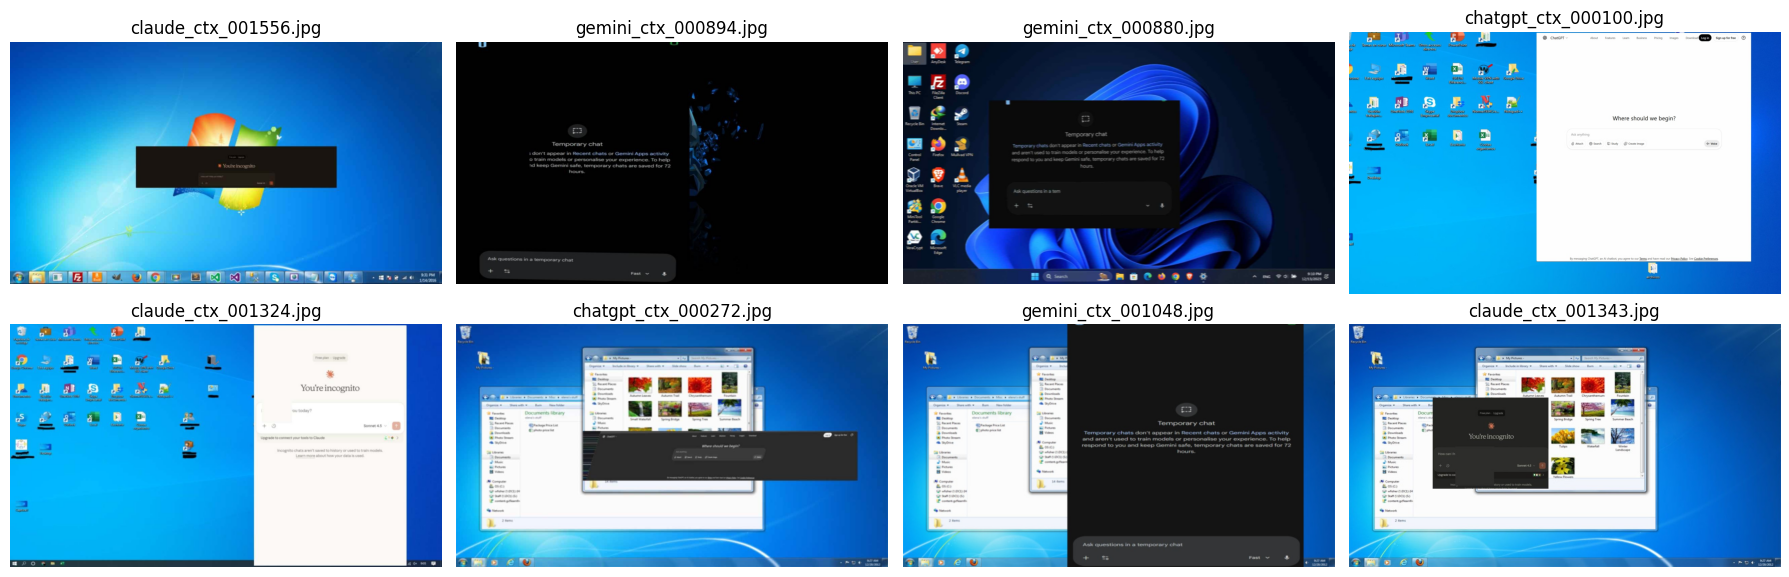

In [14]:
# Visualize some random samples from the output directory
def show_random_samples(n=8):
    files = list(OUT_DIR.glob("*.jpg")) 
    random.shuffle(files)
    files = files[:n]

    # Plot images in a grid
    plt.figure(figsize=(18, 6))
    for i, p in enumerate(files, 1):
        img = cv2.imread(str(p))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(2, (n+1)//2, i)
        plt.imshow(img)
        plt.title(p.name[:22])
        plt.axis("off")
    plt.tight_layout()
    plt.show()

show_random_samples(8)
